# 명함검출 및 인식

## 일반적인 명함 사진의 조건 (이번 예제)
- 명함은 흰색 배경에 검정색 글씨이다.
- 명함은 충분히 크게 촬영되었다.
- 명함은 각진 사각형 모양이다.

# import

In [1]:
import sys, os
import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image
import requests
from io import BytesIO  # binary 파일 입출력

base_path = r"/Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset/ComputerVision/namecard"

def cv2_imshow(image):
    cv2.imshow('image', image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

def plt_imshow(image, axis=True):  # OpenCV 이미지를 matplotlib 으로 출력하기
    img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis(axis)
    plt.show()        


# 이미지 읽어오기

In [2]:
# 이번 예제에 사용할 영상(이미지) 3장 읽어오기
src1 = cv2.imread(os.path.join(base_path, 'namecard1.jpg'))
src2 = cv2.imread(os.path.join(base_path, 'namecard2.jpg'))
src3 = cv2.imread(os.path.join(base_path, 'namecard3.jpg'))


if src1 is None or src2 is None or src3 is None:
    print('image load failed')
    sys.exit()

# h x w 확인
src1.shape, src2.shape, src3.shape    
# ((810, 1080, 3), (810, 1080, 3), (1080, 1440, 3)) 

((810, 1080, 3), (810, 1080, 3), (1080, 1440, 3))

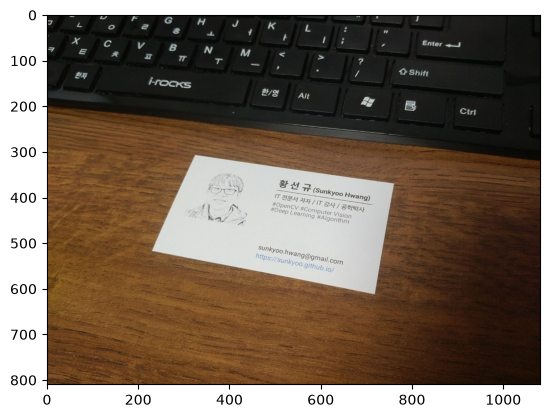

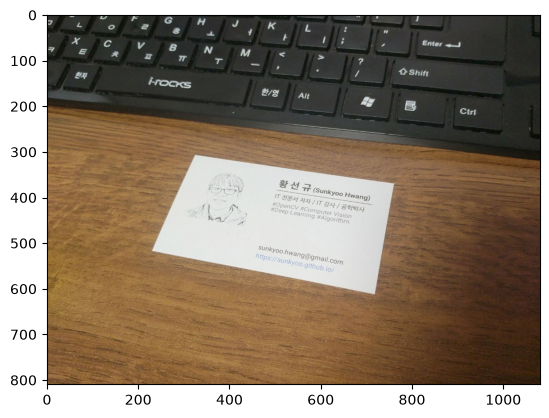

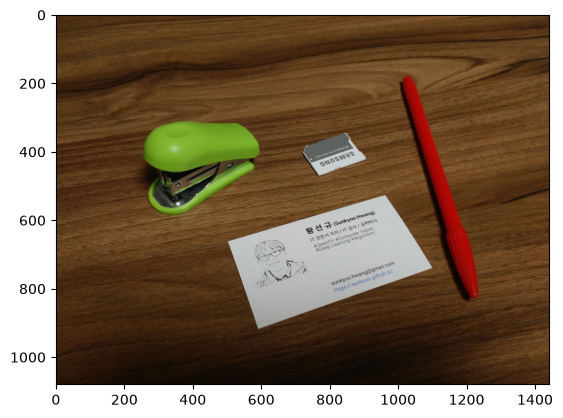

In [3]:
# 확인해보기
plt_imshow(src1)
plt_imshow(src2)
plt_imshow(src3)

# Resize

(810, 1080, 3) -> (480, 640, 3)


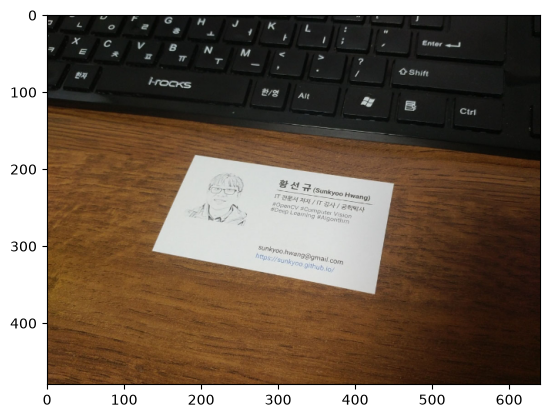

In [4]:
src_resized1 = cv2.resize(src1, (640, 480))

print(src1.shape, '->', src_resized1.shape) 

plt_imshow(src_resized1)


(405, 540, 3) (405, 540, 3) (540, 720, 3)


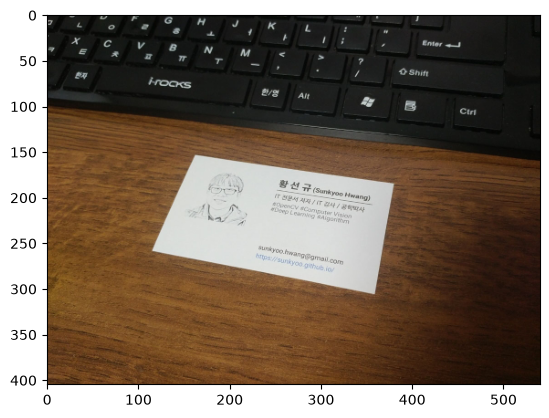

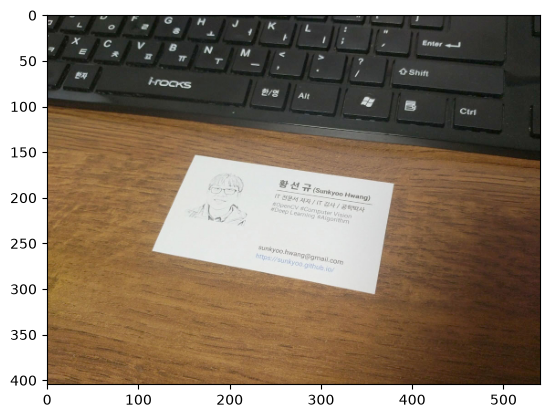

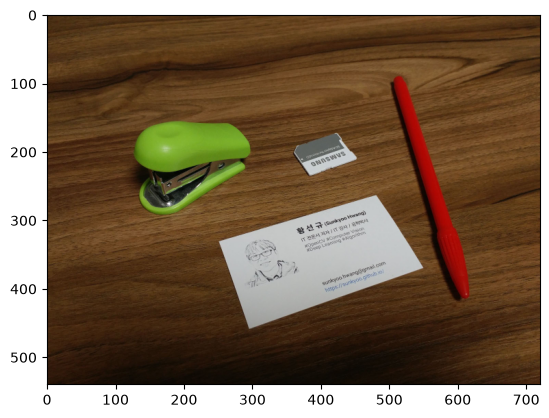

In [5]:
src_resized1 = cv2.resize(src1, (0, 0), fx=0.5, fy=0.5)
src_resized2 = cv2.resize(src2, (0, 0), fx=0.5, fy=0.5)
src_resized3 = cv2.resize(src3, (0, 0), fx=0.5, fy=0.5)

print(src_resized1.shape, src_resized2.shape, src_resized3.shape)

plt_imshow(src_resized1)
plt_imshow(src_resized2)
plt_imshow(src_resized3)


In [6]:
# ↑ 결과 .  원본대비 50% 로 resize 됨

# 📌실제 문자 인식할때는 오히려 글자를 키우는 경우가 많다

## grayscale 화 하기

In [7]:
# 일단 graysacle 로 만든다음 이진화 하는게 일반적이다
# grayscale 은 한 pixel 당 1byte 라서.
# 이미지 프로세싱 과정에서 적은 용량을 차지하는 지라, 
# 꼭 컬러 정보가 필요없는 경우에는 grayscale 로 변환한뒤 처리하는게 일반적이다

# 실제 스마트폰에 들어가 있는 얼굴 인식 프로그램들이 컬러값을 거의 사용안합니다
# 내부적으로 grayscale 로 변환하여 검증합니다

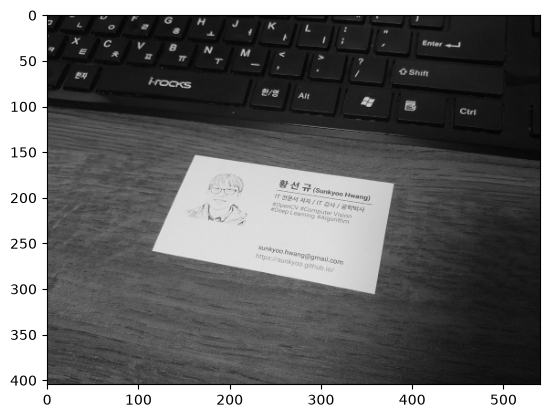

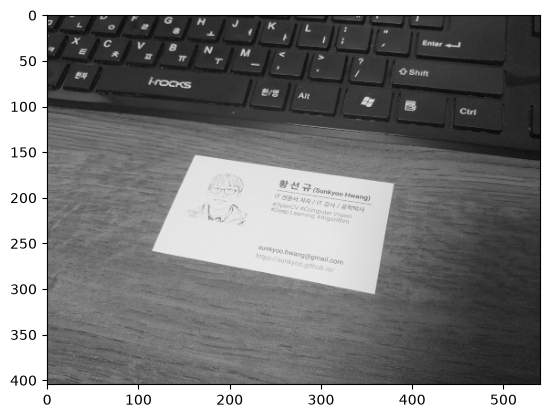

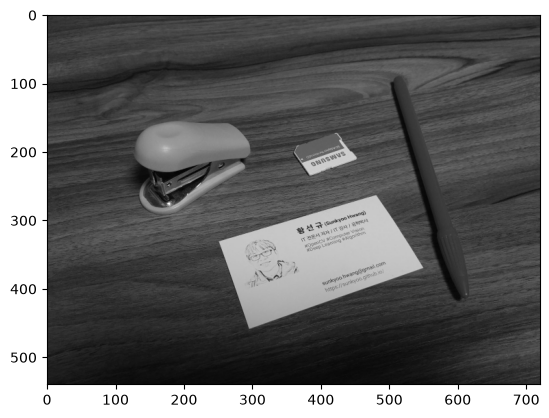

In [8]:
src_gray1 = cv2.cvtColor(src_resized1, cv2.COLOR_BGR2GRAY)
src_gray2 = cv2.cvtColor(src_resized2, cv2.COLOR_BGR2GRAY)
src_gray3 = cv2.cvtColor(src_resized3, cv2.COLOR_BGR2GRAY)

plt_imshow(src_gray1)
plt_imshow(src_gray2)
plt_imshow(src_gray3)


## 이지화: threshold() 함수

In [9]:
# 이제 위의 grayscale 변환되 이미지를 사용하여 이진화 하겠습니다
# threshold() 사용 (임계값 함수)

# cv2.threshold(src, thresh, maxval, type, dst=None)
# -> retval, dst

# src: 입력 영상. (다채널, 8비트 또는 32비트 실수형)  임계값
# thresh: THRESH_BINARY 또는 THRESH_BINARY_INV 방법을
# maxval: 사용할 때의 최댓값 지정
#        임계값에 의한 변환 함수 지정 또는 자동 임계값 설정 방법  지정 (cv.ThresholdTypes)

# retval: 사용된 임계값
# dst : (출력) 입계값 영상 (src와 동일 크기, 동일 타입)


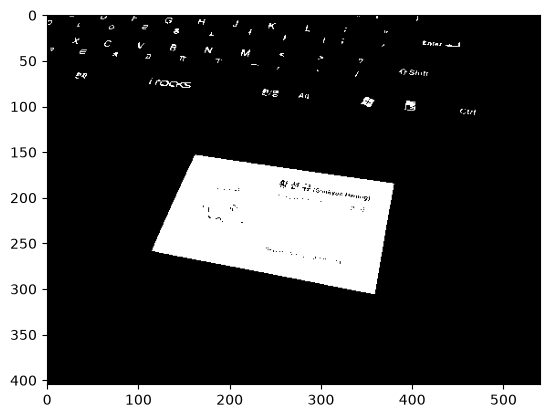

In [10]:
_, src_bin1 = cv2.threshold(src_gray1, 130, 255, cv2.THRESH_BINARY)
plt_imshow(src_bin1)

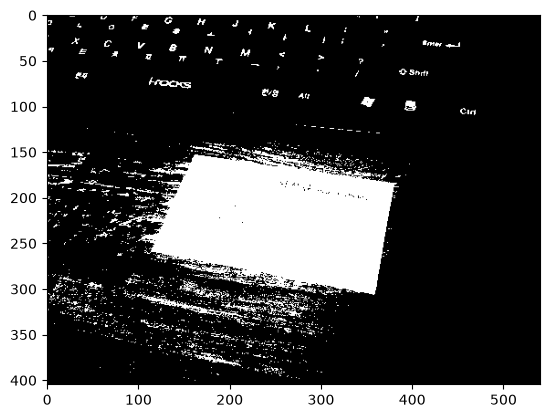

In [11]:
_, src_bin2 = cv2.threshold(src_gray2, 130, 255, cv2.THRESH_BINARY)
plt_imshow(src_bin2)

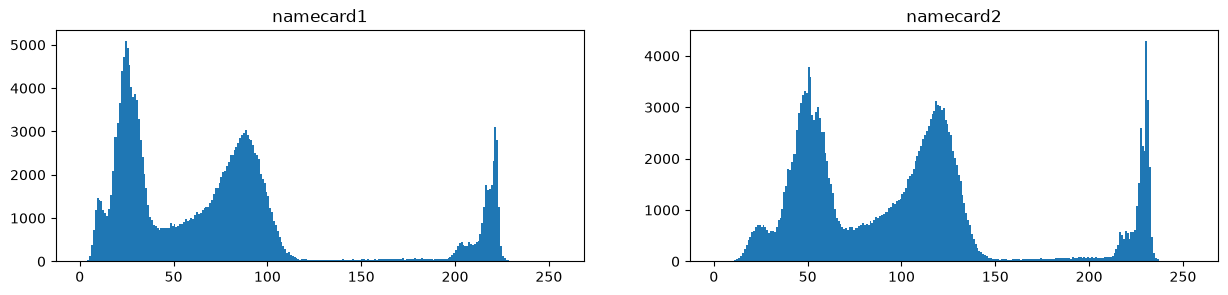

In [12]:
# 입력 영상의 밝기 다른 경우. 각각의 히스토그램을 보면.

plt.figure(figsize=(15,3))
plt.subplot(121), plt.title('namecard1'), 
plt.hist(src_gray1.ravel(), bins=256, range=[0, 256])
plt.subplot(122), plt.title('namecard2'), 
plt.hist(src_gray2.ravel(), bins=256, range=[0, 256])
plt.show()

In [13]:
# 자동으로 threshold 값 결정하는 방법

## Otsu threshold 를 사용한 이진화

152.0


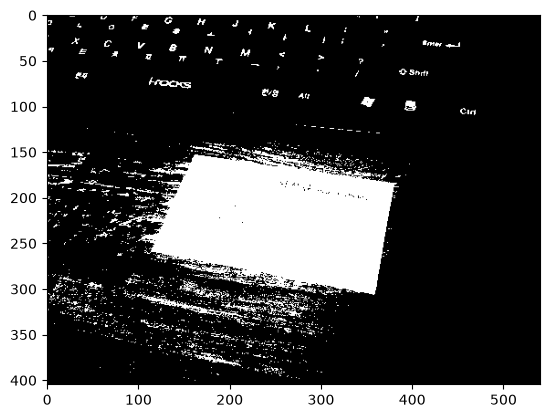

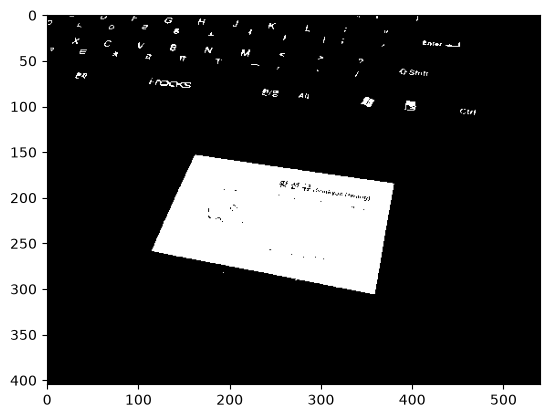

In [14]:
_, src_before = cv2.threshold(src_gray2, 130, 255, cv2.THRESH_BINARY)
th, src_after = cv2.threshold(src_gray2, 
                              0,   # 0으로 둔다 (otsu 로 결정되게 할거다) 
                              255, 
                              cv2.THRESH_BINARY | cv2.THRESH_OTSU)

print(th)

plt_imshow(src_before)
plt_imshow(src_after)



132.0 152.0 118.0


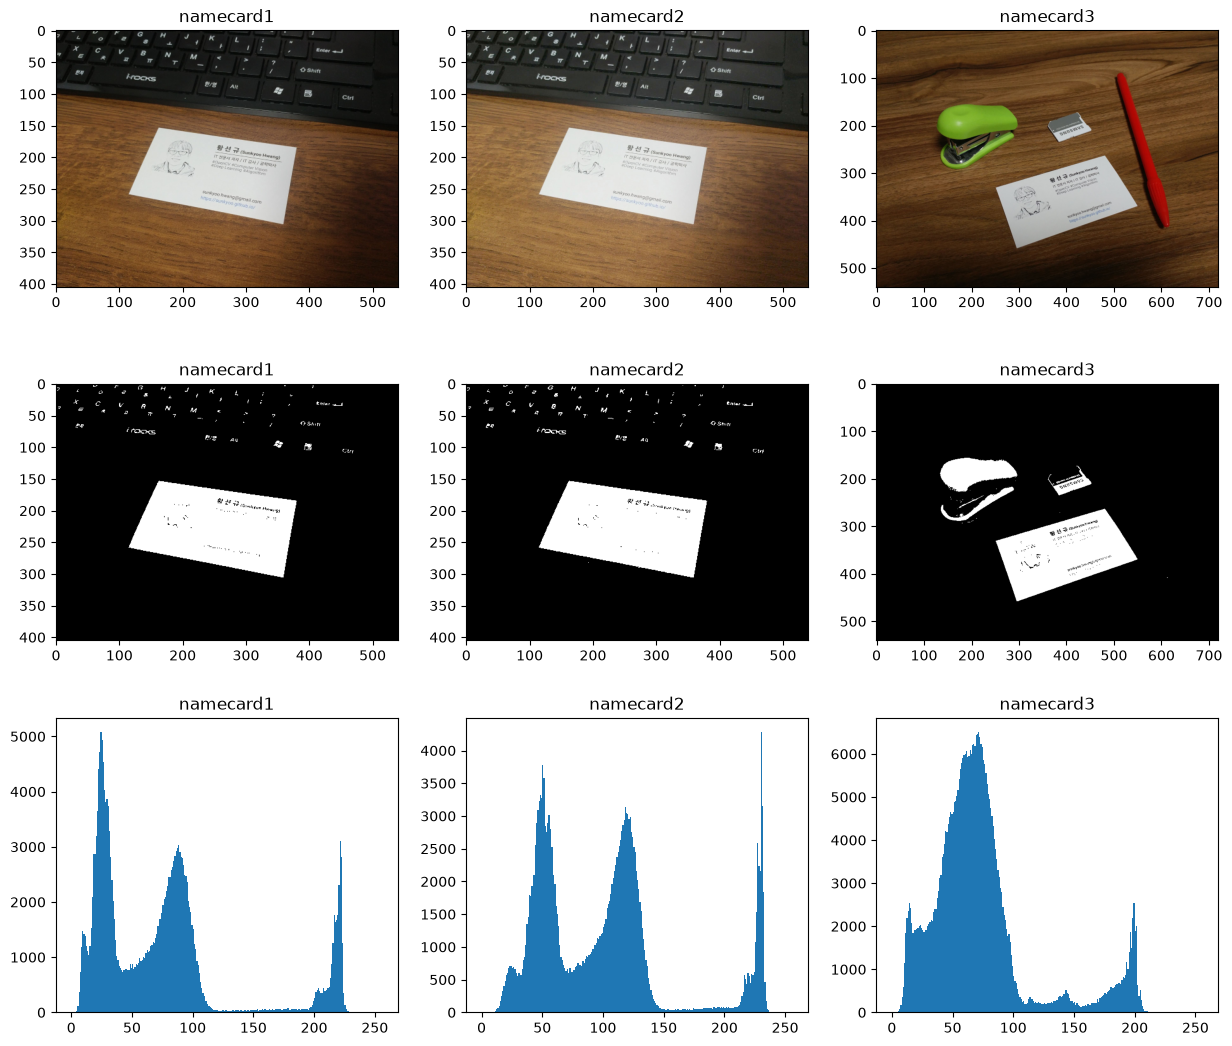

In [15]:
th1, src_bin1 = cv2.threshold(src_gray1, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
th2, src_bin2 = cv2.threshold(src_gray2, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU) 
th3, src_bin3 = cv2.threshold(src_gray3, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU) 

print(th1, th2, th3) # <- 결정된 threshold 값 확인

plt.figure(figsize=(15,13))
plt.subplot(331), plt.title('namecard1') 
plt.imshow(cv2.cvtColor(src_resized1, cv2.COLOR_BGR2RGB))
plt.subplot(332), plt.title('namecard2')
plt.imshow(cv2.cvtColor(src_resized2, cv2.COLOR_BGR2RGB))
plt.subplot(333), plt.title('namecard3')
plt.imshow(cv2.cvtColor(src_resized3, cv2.COLOR_BGR2RGB))

plt.subplot(334), plt.title('namecard1'), plt.imshow(src_bin1, cmap='gray')
plt.subplot(335), plt.title('namecard2'), plt.imshow(src_bin2, cmap='gray')
plt.subplot(336), plt.title('namecard3'), plt.imshow(src_bin3, cmap='gray')

# histogram 도 확인해보자 otsu 가 threshold 값을 어케 설정했는지 확인해보자
plt.subplot(337), plt.title('namecard1'), plt.hist(src_gray1.ravel(), bins=256, range=[0, 256])
plt.subplot(338), plt.title('namecard2'), plt.hist(src_gray2.ravel(), bins=256, range=[0, 256])
plt.subplot(339), plt.title('namecard3'), plt.hist(src_gray3.ravel(), bins=256, range=[0, 256])
plt.show()


# 객체단위 분석

## 외곽선 검출

In [16]:
contours, _ = cv2.findContours(
    src_bin1,   # image
    cv2.RETR_EXTERNAL,  # mode
    cv2.CHAIN_APPROX_NONE,  # method
)

contours[:3]   # 'array 들의 tuple'



(array([[[163, 153]],
 
        [[162, 154]],
 
        [[162, 155]],
 
        ...,
 
        [[166, 154]],
 
        [[165, 154]],
 
        [[164, 154]]], shape=(686, 1, 2), dtype=int32),
 array([[[458, 107]],
 
        [[457, 108]],
 
        [[456, 108]],
 
        [[457, 108]]], dtype=int32),
 array([[[469, 105]],
 
        [[468, 106]],
 
        [[468, 107]],
 
        [[468, 108]],
 
        [[468, 109]],
 
        [[468, 108]],
 
        [[468, 107]],
 
        [[469, 106]]], dtype=int32))

In [17]:
# ↑
# (array([[[163, 153]], 
#         [[162, 154]], 
#         [[161, 155]], 
#         ...,
#  ↑ 각각의 객체의 외곽선 정보들이 있다.

# 객체 하나의 외곽선 표현 방법 
# shape=(K,1,2) dtype=int32 (K 는 외곽선 좌표 개수)   (※ 중간의 1 은 dummy 차원..)

In [18]:
print(len(contours))

# 88개의 객체들이 있다는 뜻.  (키보드 위의 자잘한 contours 들까지 계산되었슴)

# 첫번째 객체의 외곽선
print(contours[0].shape)
# (686, 1, 2)    <--- 686개의 외곽선 좌표!?

# 첫번째 객체의 첫번째 좌표값
print(contours[0][0])

88
(686, 1, 2)
[[163 153]]


In [19]:
# 과연 88개의 객체들 중에서 내가 원하는 '명함' 이미지는 어떻게 찾아내나?

In [20]:
# 지저분한 edge 들을 제거하고, 명함의 사각형 찾기.
# contours 의 '면적'을 구하거나 혹은 '외곽선 길이'를 구할수 있다.

## 일단 외곽선들 그려보기

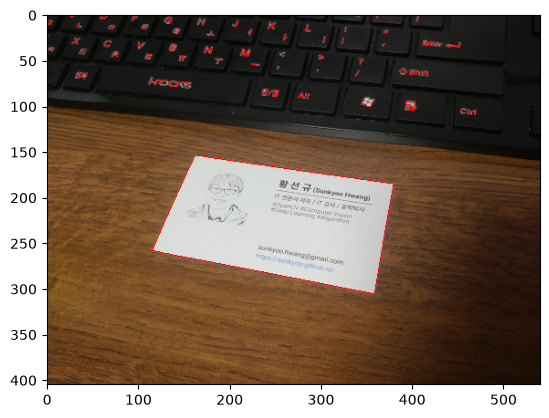

In [21]:
src_temp = src_resized1.copy()

for pts in contours:
    cv2.polylines(
        src_temp,  
        pts,
        True,   # isClosed=True 로 그리기
        (0, 0, 255)
    )

plt_imshow(src_temp)

## 면적이 특정 크키보다 작은 객체는 빼기

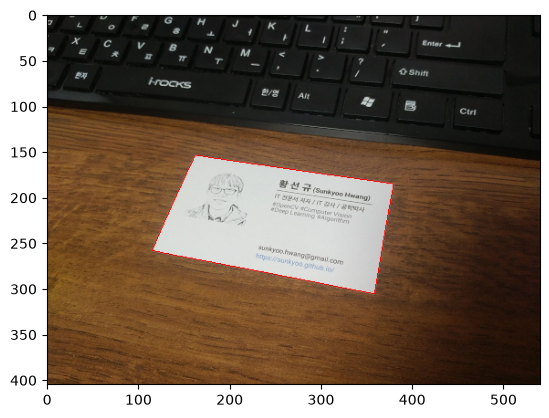

In [22]:
src_temp = src_resized1.copy()

contours, _ = cv2.findContours(
    src_bin1, 
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE,
)


for pts in contours:

    # 객체의 면적이 1000 이하이면 제거
    if cv2.contourArea(pts) < 1000: continue
    
    cv2.polylines(
        src_temp,  
        pts,
        True,   # isClosed=True 로 그리기
        (0, 0, 255)
    )

plt_imshow(src_temp)

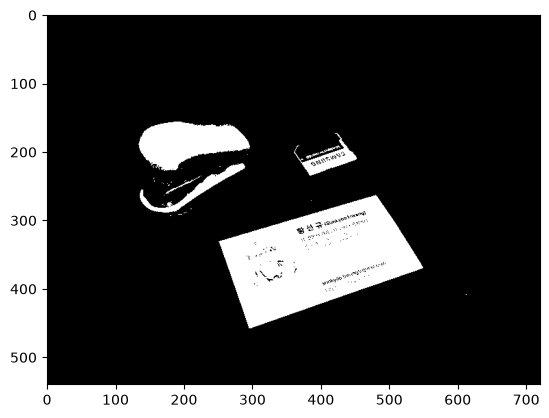

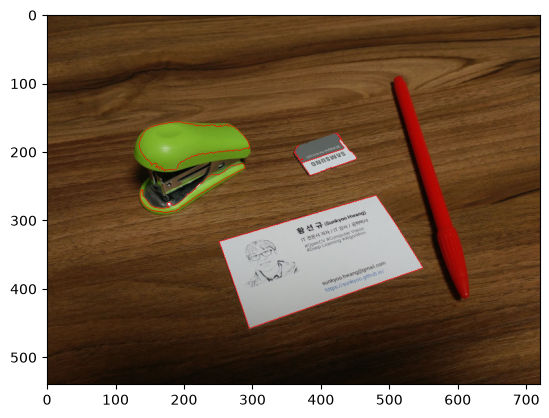

In [23]:
src_temp = src_resized3.copy()

contours, _ = cv2.findContours(
    src_bin3, 
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE,
)


for pts in contours:

    # 객체의 면적이 1000 이하이면 제거
    if cv2.contourArea(pts) < 1000: continue
    
    cv2.polylines(
        src_temp,  
        pts,
        True,   # isClosed=True 로 그리기
        (0, 0, 255)
    )

plt_imshow(src_bin3)
plt_imshow(src_temp)

In [24]:
# 일단 면적만 가지고 그럭저럭 걸러낼수 있지만,
# 여기서 좀더 처리해 주어야 한다.  --> 근사화(approx) 함수

## 근사화 함수 사용

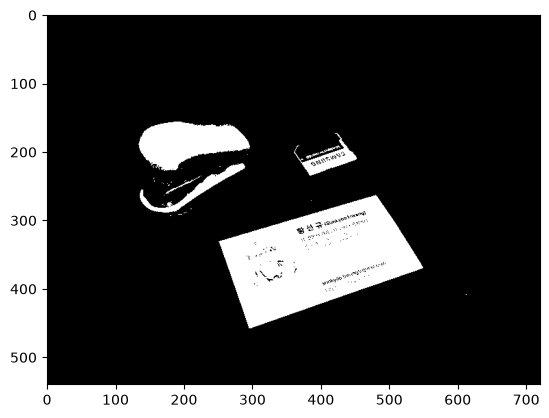

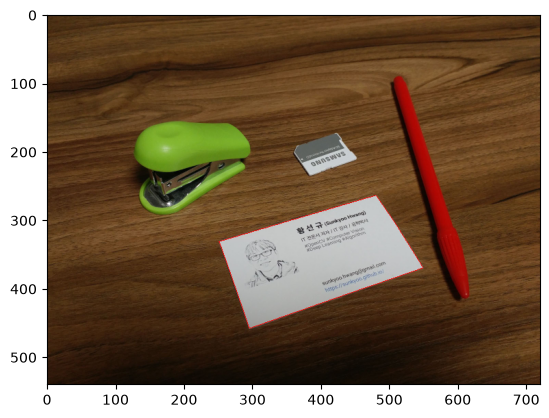

In [25]:
src_temp = src_resized3.copy()

contours, _ = cv2.findContours(
    src_bin3, 
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE,
)


for pts in contours:

    if cv2.contourArea(pts) < 1000: continue

    # 근사화 함수
    approx = cv2.approxPolyDP(
        pts,
        cv2.arcLength(pts, True) * 0.02,   # epsilon
        True,  # closed
    )

    # 위 결과가 4개의 점으로 근사화 된것만 다룸
    if len(approx) != 4: continue
    
    cv2.polylines(
        src_temp,  
        pts,
        True,   # isClosed=True 로 그리기
        (0, 0, 255)
    )

plt_imshow(src_bin3)
plt_imshow(src_temp)

## 우전 4점의 위치 출력 확인

[[[549 368]]

 [[480 263]]

 [[251 331]]

 [[295 457]]]
(4, 1, 2)


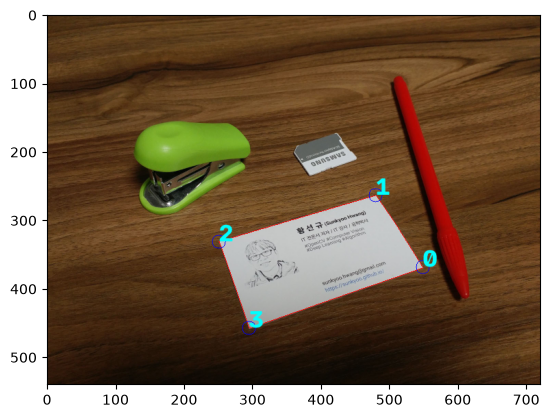

In [26]:
src_temp = src_resized3.copy()

contours, _ = cv2.findContours(
    src_bin3, 
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE,
)

for pts in contours:

    if cv2.contourArea(pts) < 1000: continue

    # 근사화 함수
    approx = cv2.approxPolyDP(
        pts,
        cv2.arcLength(pts, True) * 0.02,   # epsilon
        True,  # closed
    )

    # 위 결과가 4개의 점으로 근사화 된것만 다룸
    if len(approx) != 4: continue

    print(approx)
    print(approx.shape)
    
    cv2.polylines(
        src_temp,  
        pts,
        True,   # isClosed=True 로 그리기
        (0, 0, 255)
    )


    # approx 4개의 위치를 순서대로 출력해보고 확인해보자.
    for i, corner in enumerate(approx):
        cv2.circle(src_temp,
                   center = corner[0],
                   radius = 10,
                   color = (255,0,0)
                  )
        cv2.putText(src_temp,
                   text=str(i),
                    org = corner[0],
                    fontFace = 2, 
                    fontScale = 1.2,
                    color = (255, 255, 0),
                   )

plt_imshow(src_temp)

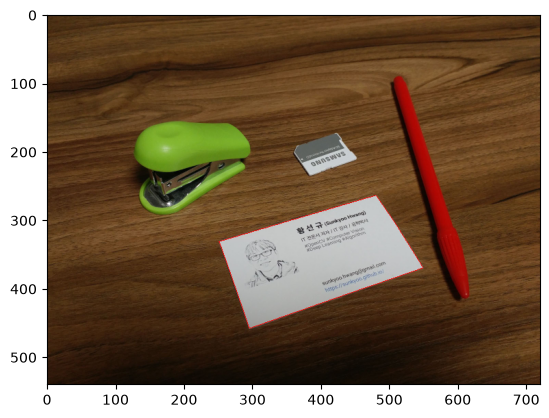

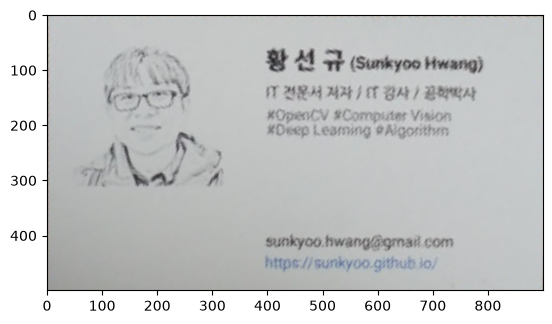

In [27]:
# 네 꼭지점이 위 순서대로 되어 있다는 전제로 작성하게 되면...

src_temp = src_resized3.copy()

contours, _ = cv2.findContours(
    src_bin3, 
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE,
)

for pts in contours:

    if cv2.contourArea(pts) < 1000: continue

    # 근사화 함수
    approx = cv2.approxPolyDP(
        pts,
        cv2.arcLength(pts, True) * 0.02,   # epsilon
        True,  # closed
    )

    # 위 결과가 4개의 점으로 근사화 된것만 다룸
    if len(approx) != 4: continue

    # 4개의 점
    srcQuad = np.array([
        approx[0, 0], approx[1, 0],
        approx[2, 0], approx[3, 0],
    ]).astype(np.float32)

    w, h = 900, 500  # 적절한 명함 사이즈

    # 변환할 4개의 점. 일단 '수동'으로 지정
    dstQuad = np.array([
        [w, h], [w, 0],
        [0, 0], [0, h],
    ]).astype(np.float32)

    pers = cv2.getPerspectiveTransform(srcQuad, dstQuad)  # 변환행렬 3x3 리턴
    dst = cv2.warpPerspective(src_temp, pers, (w, h))
    
    cv2.polylines(
        src_temp,  
        pts,
        True,   # isClosed=True 로 그리기
        (0, 0, 255)
    )

plt_imshow(src_temp)
plt_imshow(dst)


In [28]:
# 뭔가 명함이 직사각형으로 나오긴 했는데... 문제가 있다

# 1. 아까 언급했던 문제가 있다. 
# 즉 approx <- 4개의 모서리 좌표의 순서가 어케 될른지 모른다.
# 위 예제에서는 직접 수동으로 확인하고 수동으로 dstQuad 에 지정해주었다.

# 2. 또한 ... 이미지가 확대되니 뿌옇게 나온다..  글씨를 알아보기 힘들다.
#  지금은 resize 된 거라 더더욱 그렇다.

In [29]:

"""
findContours로 얻은 4개의 꼭짓점(사각형)을
  항상 같은 순서로 정렬하려면 어떻게 해야 할까?

가령
pts = np.array([
    [x1, y1],
    [x2, y2],
    [x3, y3],
    [x4, y4],
])

이를 아래와 같은 순서로 고정하고 싶다면
  [좌상, 좌하, 우하, 우상]  (또는 이와 유사한 고정된 순서)

핵심 아이디어
- x좌표 기준으로 왼쪽 2점 / 오른쪽 2점 분리
- 각 쌍에서 y좌표로 위/아래 정렬

"""
None

In [30]:
pts = np.array(
    # [x ,  y]
    [[300, 100],
     [100, 200],
     [300, 400],
     [100,  50]]
)

# np.lexsort((seconday_key, primary_key))
# 1차기준: pts[:, 0] -> x 좌표
# 2차기준: pts[:, 1] -> y 좌표
idx = np.lexsort((pts[:, 1], pts[:, 0]))
print(idx)
pts[idx]

# array([[100,  50],   # 왼쪽 + 위
#        [100, 200],   # 왼쪽 + 아래
#        [300, 100],   # 오른쪽 + 위
#        [300, 400]])  # 오른쪽 + 아래

[3 1 0 2]


array([[100,  50],
       [100, 200],
       [300, 100],
       [300, 400]])

In [31]:
# [왼쪽 점 1, 왼쪽 점 2, 오른쪽 점 1, 오른쪽 점 2]
# 하지만 왼쪽/오른쪽 내부에서 위/아래 순서는 보장되지 않음
# → 그래서 다음 단계가 필요합니다.

In [32]:
# 왼쪽 두점 위/아래 정렬
# pts[0], pts[1] -> 왼쪽 두 점

if pts[0, 1] > pts[1, 1]:
    pts[[0, 1]] = pts[[1, 0]]  # 교환.

# 오른쪽 두점 pts[2], pts[3] 위 아래 정렬
if pts[2, 1] < pts[3, 1]:
    pts[[2, 3]] = pts[[3, 2]]  # 교환

pts

array([[300, 100],
       [100, 200],
       [300, 400],
       [100,  50]])

## OCR 하기

In [33]:
import pytesseract

In [42]:
dst_rgb = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)
print(pytesseract.image_to_string(dst_rgb, lang='script/Hangul+eng'))


~

gy

황 선 규 (Sunkyoo Hwang)

IT 전문서 저자 / IT 강사 / 공 학 박사

#OpenCV #Computer Vision
#Deep Learning #Algorithm

sunkyoo.hwang@gmail.com
https://sunkyoo.github.io/




# 종합

In [35]:
import sys
import numpy as np
import cv2
import pytesseract


def reorderPts(pts):
    idx = np.lexsort((pts[:, 1], pts[:, 0]))  # 칼럼0 -> 칼럼1 순으로 정렬한 인덱스를 반환
    pts = pts[idx]  # x좌표로 정렬

    if pts[0, 1] > pts[1, 1]:
        pts[[0, 1]] = pts[[1, 0]]

    if pts[2, 1] < pts[3, 1]:
        pts[[2, 3]] = pts[[3, 2]]

    return pts

In [36]:
# 영상 불러오기
filename = 'namecard1.jpg'
src = cv2.imread(os.path.join(base_path, filename))


In [37]:
# 출력 영상 설정
dw, dh = 720, 400
srcQuad = np.array([[0, 0], [0, 0], [0, 0], [0, 0]], np.float32)
dstQuad = np.array([[0, 0], [0, dh], [dw, dh], [dw, 0]], np.float32)
dst = np.zeros((dh, dw), np.uint8)


In [38]:
# 입력 영상 전처리
src_gray = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)
th, src_bin = cv2.threshold(src_gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

# 외곽선 검출 및 명함 검출
contours, _ = cv2.findContours(src_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)


In [39]:
for pts in contours:
    # 너무 작은 객체는 제외
    if cv2.contourArea(pts) < 1000:
        continue

    # 외곽선 근사화
    approx = cv2.approxPolyDP(pts, cv2.arcLength(pts, True)*0.02, True)

    # 꼭지점이 4개가 아니거나,  컨벡스(볼록)한 형태가 아니면 제외
    if not cv2.isContourConvex(approx) or len(approx) != 4:
        continue

    # print(len(approx))

    cv2.polylines(src, [approx], True, (0, 255, 0), 2, cv2.LINE_AA)
    srcQuad = reorderPts(approx.reshape(4, 2).astype(np.float32))  # !!

    pers = cv2.getPerspectiveTransform(srcQuad, dstQuad)
    dst = cv2.warpPerspective(src, pers, (dw, dh), 
                              flags=cv2.INTER_CUBIC  # 영상 확대/축소등이 발생될때 interpolation 방식
                                                  # 디폴트는 INTER_LIN (linear) 인데
                                                  # 좀더 좋은 화질을 위해 INTER_CUBIC 사용
                                                  # OpenCV 에선 INTER_LANCZOS4 방식도 좋다.
                             )

In [40]:
dst_rgb = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)
print(pytesseract.image_to_string(dst_rgb, lang='Hangul+eng'))


~

gy

Ely 4 7 (Sunkyoo Hwang)

IT ABA Alat / IT BAt/ SStByAt

#OpenCV #Computer Vision
#Deep Learning #Algorithm

sunkyoo.hwang@gmail.com
https://sunkyoo.github.io/




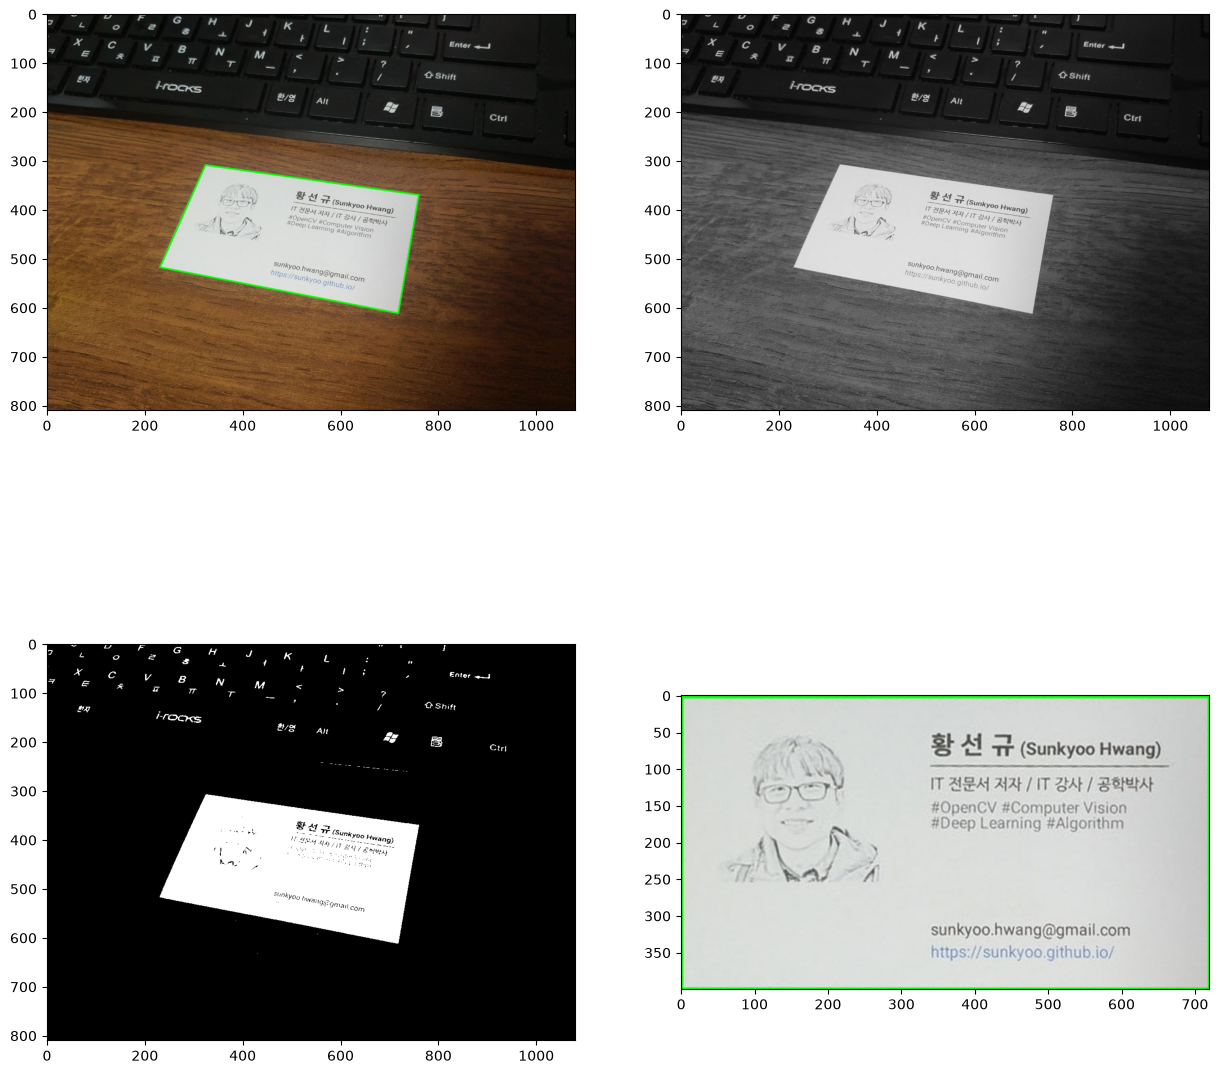

In [41]:
plt.figure(figsize=(15,15))
plt.subplot(221), plt.imshow(cv2.cvtColor(src, cv2.COLOR_BGR2RGB))
plt.subplot(222), plt.imshow(src_gray, cmap='gray')
plt.subplot(223), plt.imshow(src_bin, cmap='gray')
plt.subplot(224), plt.imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
plt.show()
